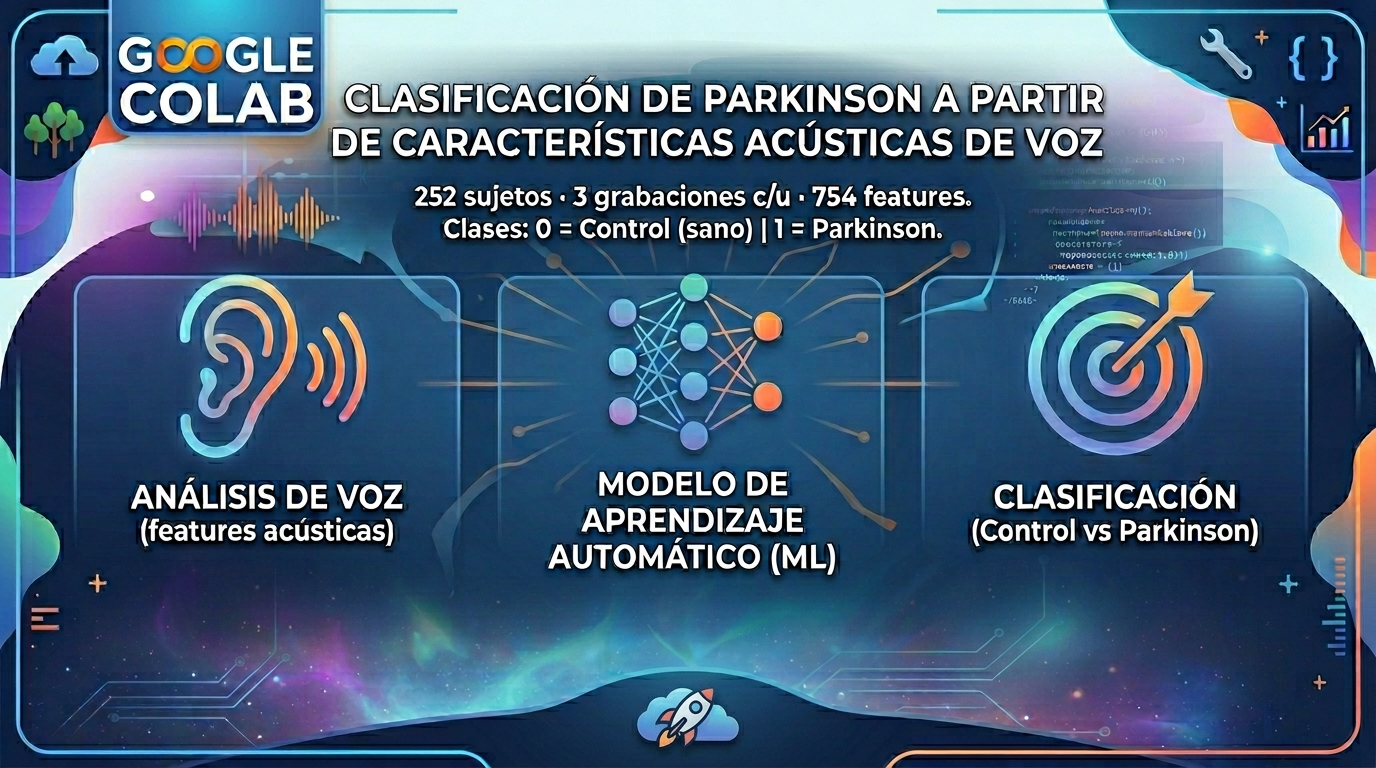

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# =============================================================================
#  CONFIGURACIÓN
# =============================================================================
SEMILLA         = 42
RUTA_CSV        = "pd_speech_features.csv"
ID, TARGET      = "id", "class"
PROPORCION_TEST = 0.20
FOLDS           = 5

# Configuraciones para los experimentos
pesos             = [("sin_pesos",{0:1,1:1}),("peso_2",{0:2,1:1}),("peso_3",{0:3,1:1}),
                     ("peso_4",{0:4,1:1}),("peso_5",{0:5,1:1})]
features_a_probar = [10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 200]

# CARGA Y PREPARACIÓN

In [ ]:
def cargar_datos(ruta):
    datos = pd.read_csv(ruta, header=1).dropna(axis=1, how="all")
    datos[ID]     = datos[ID].astype(int)
    datos[TARGET] = datos[TARGET].astype(int)
    for col in datos.columns:
        if col not in [ID, TARGET]:
            datos[col] = pd.to_numeric(datos[col], errors="coerce")
    return datos.dropna().reset_index(drop=True)


def separar_variables(datos):
    return datos.drop(columns=[ID, TARGET]), datos[TARGET], datos[ID]

# VISUALIZACIÓN

In [ ]:
def mostrar_metricas(nombre, m):
    sep = "─" * 60
    print(f"\n{sep}\n  📊 {nombre.upper()}\n{sep}")
    for k, v in m.items():
        print(f"  {k.replace('_',' ').title():<22}: {v:.4f}")
    print(sep)
    print("\n")

def plot_confusion(matriz, titulo):
    _, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Control","Parkinson"], yticklabels=["Control","Parkinson"], ax=ax)
    ax.set(title=titulo, ylabel="Etiqueta Real", xlabel="Predicción del Modelo")
    plt.tight_layout(); plt.show()
    print("\n")

def plot_roc(y_real, proba, titulo):
    _, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_real, proba, color="darkorange", ax=ax)
    ax.plot([0,1],[0,1], "--", color="navy", label="Aleatorio (AUC=0.5)")
    ax.set_title(titulo); ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()
    print("\n")

def plot_importancia(ranking, top_n=20):
    _, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=ranking.head(top_n), x="importancia", y="variable",
                hue="variable", legend=False, palette="viridis", ax=ax)
    ax.set_title(f"Top {top_n} Biomarcadores Más Importantes")
    plt.tight_layout(); plt.show()
    print("\n")

def plot_umbral(res, mejor_umbral):
    _, ax = plt.subplots(figsize=(10, 5))
    ax.plot(res["umbral"], res["balanced_accuracy"], label="Balanced Accuracy", lw=2,   color="#2ecc71")
    ax.plot(res["umbral"], res["recall_control"],    label="Recall Control",    lw=1.5, color="#3498db", ls="-.")
    ax.plot(res["umbral"], res["recall_parkinson"],  label="Recall Parkinson",  lw=1.5, color="#e74c3c", ls="-.")
    ax.axvline(mejor_umbral, ls="--", color="gray", label=f"Mejor umbral = {mejor_umbral:.2f}")
    ax.set(xlabel="Umbral de Decisión", ylabel="Score", title="Búsqueda de Umbral Óptimo")
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
    print("\n")

def plot_comparativa(df, titulo, col_x, col_y="BA_sujeto"):
    _, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(df[col_x].astype(str), df[col_y],
                  color=sns.color_palette("viridis", len(df)), edgecolor="white", width=0.6)
    for b, v in zip(bars, df[col_y]):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
    ax.set(title=titulo, ylabel="Balanced Accuracy (por Sujeto)", ylim=(0, 1.05))
    ax.axhline(0.8, color="gray", ls="--", alpha=0.4); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()
    print("\n")

def plot_distribucion_clases(datos, col_target, titulo):
    _, ax = plt.subplots(figsize=(5, 4))
    sns.countplot(data=datos, x=col_target, palette="Set2", ax=ax, hue=col_target, legend=False)
    ax.set_title(titulo)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Control", "Parkinson"])
    ax.set_xlabel("Clase")
    ax.set_ylabel("Cantidad de Grabaciones")
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(); plt.show()
    print("\n")

def plot_distribucion_train_test(df_stats, titulo):
    df_melt = df_stats.melt(id_vars=["Conjunto"], value_vars=["Control", "Parkinson"],
                            var_name="Clase", value_name="Cantidad_Sujetos")
    _, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(data=df_melt, x="Conjunto", y="Cantidad_Sujetos", hue="Clase", palette="Set2", ax=ax)
    ax.set_title(titulo)
    ax.set_ylabel("Cantidad de Sujetos")
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(); plt.show()
    print("\n")

def plot_mejora_baseline(metricas_base, metricas_final, titulo="Mejora: Baseline vs Final"):
    labels = ['Balanced Accuracy', 'Recall Control', 'Recall Parkinson', 'ROC AUC']
    base_vals = [metricas_base['balanced_accuracy'], metricas_base['recall_control'], metricas_base['recall_parkinson'], metricas_base['roc_auc']]
    final_vals = [metricas_final['balanced_accuracy'], metricas_final['recall_control'], metricas_final['recall_parkinson'], metricas_final['roc_auc']]

    x = np.arange(len(labels))
    width = 0.35

    _, ax = plt.subplots(figsize=(8, 5))
    rects1 = ax.bar(x - width/2, base_vals, width, label='Baseline (Sujeto, Umbral 0.5)', color='#bdc3c7')
    rects2 = ax.bar(x + width/2, final_vals, width, label='Final Optimizado', color='#2ecc71')

    ax.set_ylabel('Score')
    ax.set_title(titulo)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.15)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)
    ax.grid(axis='y', alpha=0.3)

    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()
    print("\n")

#  PIPELINE DE EJECUCIÓN

# ── PASO 1: Carga y limpieza ──────────────────────────────────────────────────
**Lee el CSV (fila 2 como encabezado), elimina columnas vacías,
convierte features a numérico y descarta filas con NaN resultantes.**

No se encontró el archivo 'pd_speech_features.csv'. Por favor, súbelo:


Saving pd_speech_features.csv to pd_speech_features.csv
Filas: 756 | Columnas: 755 | Sujetos: 252



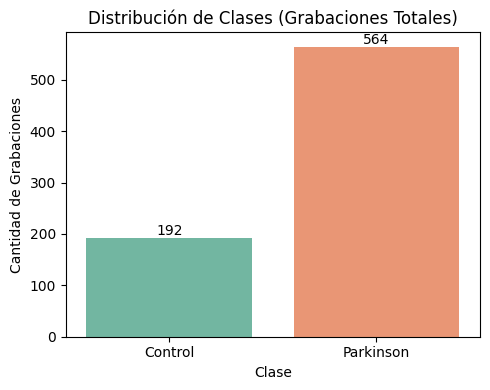

In [ ]:
def cargar_datos(ruta):
    if not os.path.exists(ruta):
        try:
            # Intento para Google Colab
            from google.colab import files  # type: ignore
            print(f"No se encontró el archivo '{ruta}'. Por favor, súbelo:")
            uploaded = files.upload()
            if not uploaded:
                raise FileNotFoundError("No se subió ningún archivo.")
            ruta = list(uploaded.keys())[0]
        except ImportError:
            try:
                # Intento para entorno local con explorador de archivos
                import tkinter as tk
                from tkinter import filedialog
                root = tk.Tk()
                root.withdraw()
                root.attributes('-topmost', True)
                print(f"No se encontró el archivo '{ruta}'. Seleccionalo en la ventana de diálogo...")
                ruta_sel = filedialog.askopenfilename(title="Seleccionar Dataset CSV", filetypes=[("Archivos CSV", "*.csv")])
                if ruta_sel:
                    ruta = ruta_sel
                else:
                    raise FileNotFoundError("No se seleccionó ningún archivo.")
            except Exception:
                raise FileNotFoundError(f"Por favor, asegúrate de colocar '{ruta}' en la misma carpeta que el código.")

    datos = pd.read_csv(ruta, header=1).dropna(axis=1, how="all")
    datos[ID]     = datos[ID].astype(int)
    datos[TARGET] = datos[TARGET].astype(int)
    for col in datos.columns:
        if col not in [ID, TARGET]:
            datos[col] = pd.to_numeric(datos[col], errors="coerce")
    return datos.dropna().reset_index(drop=True)

def separar_variables(datos):
    return datos.drop(columns=[ID, TARGET]), datos[TARGET], datos[ID]

datos = cargar_datos(RUTA_CSV)
print(f"Filas: {len(datos)} | Columnas: {datos.shape[1]} | Sujetos: {datos[ID].nunique()}\n")
plot_distribucion_clases(datos, TARGET, "Distribución de Clases (Grabaciones Totales)")

# ── PASO 2: Separación Train / Test ──────────────────────────────────────────
**GroupShuffleSplit garantiza que TODAS las grabaciones de un paciente queden 
en el mismo conjunto (train O test, nunca en ambos). Sin esto, el modelo 
podría reconocer la voz de sujetos ya vistos → data leakage.**

Conjunto  Grabaciones  Sujetos  Control  Parkinson
   Train          603      201       50        151
    Test          153       51       14         37



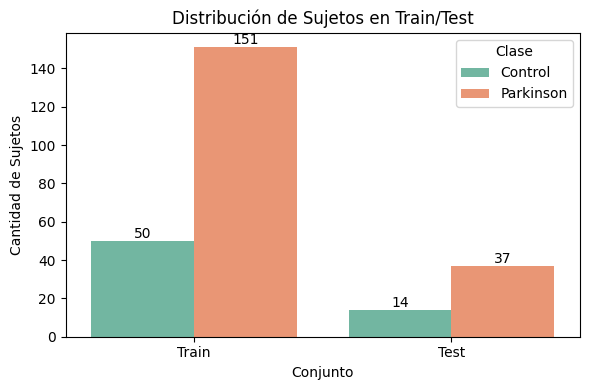

In [ ]:
x, y, grupos = separar_variables(datos)
gss = GroupShuffleSplit(n_splits=1, test_size=PROPORCION_TEST, random_state=SEMILLA)
idx_tr, idx_te = next(gss.split(x, y, grupos))
train = datos.iloc[idx_tr].reset_index(drop=True)
test  = datos.iloc[idx_te].reset_index(drop=True)
assert set(train[ID]).isdisjoint(set(test[ID]))

df_stats = pd.DataFrame({
    "Conjunto":    ["Train","Test"],
    "Grabaciones": [len(train), len(test)],
    "Sujetos":     [train[ID].nunique(), test[ID].nunique()],
    "Control":     [train[[ID,TARGET]].drop_duplicates().query(f"`{TARGET}`==0").shape[0],
                     test[[ID,TARGET]].drop_duplicates().query(f"`{TARGET}`==0").shape[0]],
    "Parkinson":   [train[[ID,TARGET]].drop_duplicates().query(f"`{TARGET}`==1").shape[0],
                     test[[ID,TARGET]].drop_duplicates().query(f"`{TARGET}`==1").shape[0]],
})
print(df_stats.to_string(index=False)+"\n")
plot_distribucion_train_test(df_stats, "Distribución de Sujetos en Train/Test")

# ── Definición del Pipeline (Plantilla)  ─────────────────────────
**Creamos una función que devuelve un 'Pipeline'.**

**Funciona como una plantilla que luego configuraremos durante los experimentos:**

1. **SimpleImputer:** Busca datos faltantes (NaN) y los rellena con el valor central (la mediana) de esa característica, para que el modelo no falle.
2. **SelectKBest (opcional):** Es la herramienta que explotaremos en el Paso 7. Por defecto arranca apagada, pero nos permitirá evaluar matemáticamente cuál es el número exacto 'K' de características que da el mejor resultado.
3. **ExtraTreesClassifier:** Es el cerebro del modelo. Crea un "bosque" de 600 árboles con cortes aleatorios para evitar memorizar los datos. Acepta el parámetro `class_weight`, lo que nos permitirá experimentar en el Paso 5 dándole distintos "pesos" o importancia a los pacientes Sanos.

**¿Por qué usar un Pipeline?**

Evita la "fuga de datos" (data leakage) o "hacer trampa sin querer". Garantiza que la mediana y la selección de variables se calculen ÚNICAMENTE mirando datos de entrenamiento de cada ronda, sin espiar jamás los datos de validación.

In [ ]:
def crear_modelo(class_weight="balanced", k_features=None):
    pasos = [("imputer", SimpleImputer(strategy="median"))]
    if k_features:
        pasos.append(("selector", SelectKBest(mutual_info_classif, k=k_features)))
    pasos.append(("modelo", ExtraTreesClassifier(
        n_estimators=600, max_depth=8, min_samples_leaf=5,
        max_features="sqrt", class_weight=class_weight,
        random_state=SEMILLA, n_jobs=-1,
    )))
    return Pipeline(pasos)

def calcular_metricas(y_real, y_pred, y_proba):
    return {
        "accuracy":          accuracy_score(y_real, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_real, y_pred),
        "precision":         precision_score(y_real, y_pred, zero_division=0),
        "recall_global":     recall_score(y_real, y_pred, zero_division=0),
        "recall_control":    recall_score(y_real, y_pred, pos_label=0, zero_division=0),
        "recall_parkinson":  recall_score(y_real, y_pred, pos_label=1, zero_division=0),
        "f1":                f1_score(y_real, y_pred, zero_division=0),
        "roc_auc":           roc_auc_score(y_real, y_proba),
    }

# ── PASO 3: Validación cruzada (GroupKFold, 5 folds) ─────────────────────────

### GroupKFold: 5 pliegues agrupados por paciente.
**Las predicciones Out-Of-Fold (OOF) se acumulan para calcular métricas globales 
y estimar el rendimiento del modelo antes de tocar el conjunto de test.**

**¿Qué es GroupKFold y por qué lo usamos?**
Divide los datos de entrenamiento en 5 "pliegues" (folds) o partes. 
La palabra clave es 'Group': garantiza que las 3 grabaciones de un mismo 
paciente vayan siempre juntas al mismo pliegue. Si un paciente se usa para 
validar en esa ronda, el modelo no pudo haber entrenado con su voz.

**¿Qué son las predicciones Out-Of-Fold (OOF)?**
En cada ronda de las 5, el modelo entrena con 4 pliegues y "predice" sobre el 5to. 
Al terminar las 5 iteraciones, TODOS los pacientes habrán sido evaluados 
exactamente una vez (cuando les tocó estar "fuera del entrenamiento" o OOF). 
Acumulamos todas estas predicciones limpias y calculamos métricas globales. 
Esto nos permite simular el rendimiento del modelo en el mundo real SIN 
tener que tocar nuestro conjunto sagrado de Test (el cual reservamos para el final).


────────────────────────────────────────────────────────────
  📊 VALIDACIÓN CRUZADA — 5-FOLD GROUPKFOLD
────────────────────────────────────────────────────────────
  Accuracy              : 0.7745
  Balanced Accuracy     : 0.6983
  Precision             : 0.8499
  Recall Global         : 0.8499
  Recall Control        : 0.5467
  Recall Parkinson      : 0.8499
  F1                    : 0.8499
  Roc Auc               : 0.7758
────────────────────────────────────────────────────────────




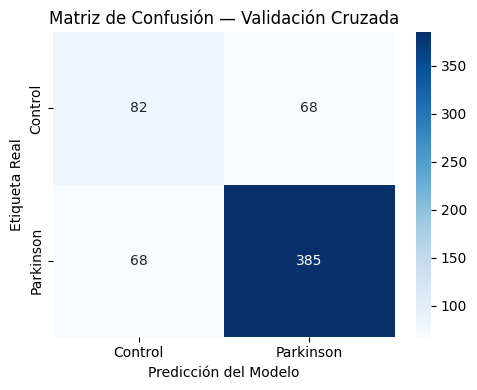

In [ ]:
def validar_con_groupkfold(datos_train, class_weight="balanced", k_features=None):
    x, y, grupos  = separar_variables(datos_train)
    pred_oof      = np.zeros(len(x), dtype=int)
    proba_oof     = np.zeros(len(x), dtype=float)
    for _, (idx_tr, idx_val) in enumerate(GroupKFold(FOLDS).split(x, y, grupos)):
        m = crear_modelo(class_weight, k_features)
        m.fit(x.iloc[idx_tr], y.iloc[idx_tr])
        pred_oof[idx_val]  = m.predict(x.iloc[idx_val])
        proba_oof[idx_val] = m.predict_proba(x.iloc[idx_val])[:, 1]
    return calcular_metricas(y, pred_oof, proba_oof), confusion_matrix(y, pred_oof)

metricas_cv, matriz_cv = validar_con_groupkfold(train)
mostrar_metricas("Validación Cruzada — 5-fold GroupKFold", metricas_cv)
plot_confusion(matriz_cv, "Matriz de Confusión — Validación Cruzada")

# ── PASO 4: Evaluación final en test ─────────────────────────────────────────
**Se entrena con TODO el train y se evalúa sobre el 20% de test (nunca visto).
Esta es la evaluación real de la capacidad del modelo de generalizar.**


────────────────────────────────────────────────────────────
  📊 TEST FINAL (POR GRABACIÓN)
────────────────────────────────────────────────────────────
  Accuracy              : 0.7974
  Balanced Accuracy     : 0.7420
  Precision             : 0.8571
  Recall Global         : 0.8649
  Recall Control        : 0.6190
  Recall Parkinson      : 0.8649
  F1                    : 0.8610
  Roc Auc               : 0.8756
────────────────────────────────────────────────────────────




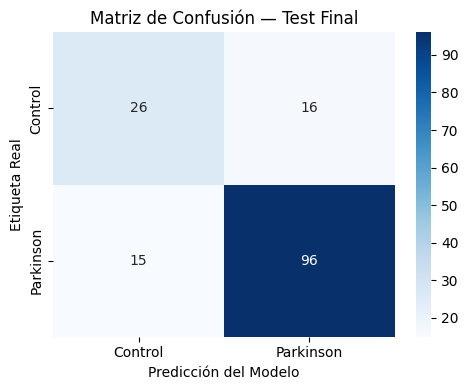

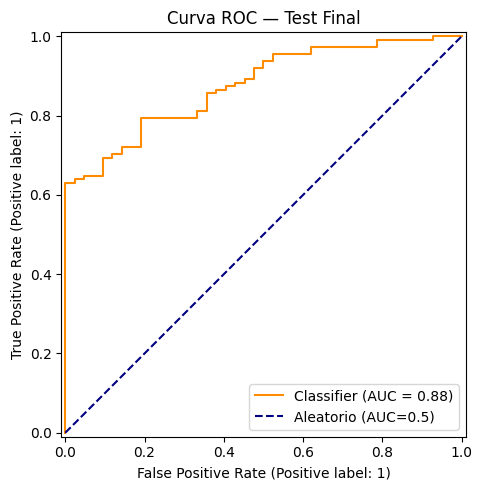

In [ ]:
def evaluar_en_test(train, test, class_weight="balanced", k_features=None):
    x_tr, y_tr, _ = separar_variables(train)
    x_te, y_te, _ = separar_variables(test)
    m = crear_modelo(class_weight, k_features)
    m.fit(x_tr, y_tr)
    pred  = m.predict(x_te)
    proba = m.predict_proba(x_te)[:, 1]
    return calcular_metricas(y_te, pred, proba), confusion_matrix(y_te, pred), m, y_te, proba, test[ID]

metricas_test, matriz_test, modelo_final, y_test, proba_test, ids_test = evaluar_en_test(train, test)
mostrar_metricas("Test Final (por grabación)", metricas_test)
plot_confusion(matriz_test, "Matriz de Confusión — Test Final")
plot_roc(y_test, proba_test, "Curva ROC — Test Final")

### Fase de Optimización y Experimentación
Hasta este punto (Paso 4), hemos establecido nuestro **modelo base (baseline)** entrenando con la totalidad de los datos acústicos (754 variables) y hemos evaluado su capacidad de generalización inicial. Si bien obtenemos un buen punto de partida, en un entorno clínico real buscamos maximizar la precisión y reducir los falsos negativos.

**Cada paciente tiene 3 grabaciones: el modelo produce una probabilidad por cada una. Para tomar una decisión clínica (¿tiene Parkinson este paciente?) se promedian esas 3 probabilidades → estimación más robusta que la de una sola grabación, que puede ser atípica por ruido, tos u otras variaciones del momento. El umbral se aplica sobre ese promedio para obtener la predicción por sujeto.**

#### Agregación de Probabilidades por Paciente

**Cada paciente tiene 3 grabaciones: el modelo produce una probabilidad por cada una. Para tomar una decisión clínica (¿tiene Parkinson este paciente?) se promedian esas 3 probabilidades → estimación más robusta que la de una sola grabación, que puede ser atípica por ruido, tos u otras variaciones del momento. El umbral se aplica sobre ese promedio para obtener la predicción por sujeto.**

In [ ]:
def evaluar_por_sujeto(ids, y_real, proba, umbral=0.5):
    df  = pd.DataFrame({"id": ids, "y_real": y_real, "proba": proba})
    pac = df.groupby("id").agg(y_real=("y_real","first"), proba_media=("proba","mean")).reset_index()
    pac["pred"] = (pac["proba_media"] >= umbral).astype(int)
    return (calcular_metricas(pac["y_real"], pac["pred"], pac["proba_media"]),
            confusion_matrix(pac["y_real"], pac["pred"]), pac)

# ── PASO 5: Experimento — Pesos de clase ─────────────────────────────────────
**Se explora primero el efecto del desbalance de clases de forma aislada, 
antes de introducir selección de features, para no mezclar las causas. 
El dataset tiene ≈3 grabaciones de Parkinson por cada Control: penalizar 
más los errores sobre la clase minoritaria puede mejorar su detección. 
Se comparan pesos crecientes para Control con umbral fijo = 0.5.**

   config  peso_clase_0  BA_sujeto  ROC_AUC
sin_pesos             1   0.665058 0.893822
   peso_2             2   0.709459 0.899614
   peso_3             3   0.745174 0.891892
   peso_4             4   0.789575 0.891892
   peso_5             5   0.806950 0.884170



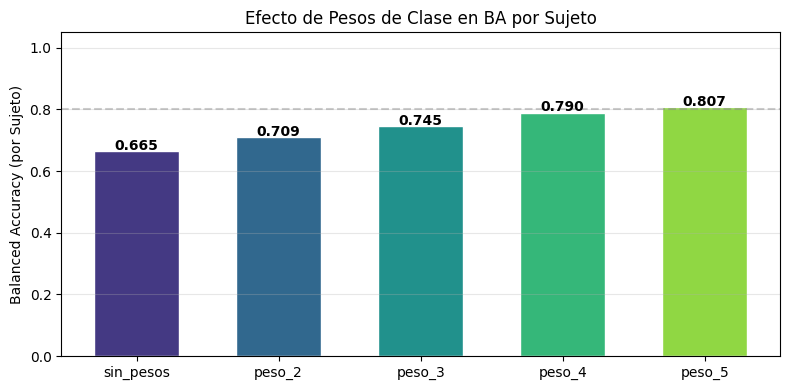

In [ ]:
resultados_pesos = []
for nombre, peso in pesos:
    _, _, _, y_p, proba_p, ids_p = evaluar_en_test(train, test, class_weight=peso)
    m_s, _, _ = evaluar_por_sujeto(ids_p, y_p, proba_p, umbral=0.5)
    resultados_pesos.append({"config": nombre, "peso_clase_0": peso[0],
                             "BA_sujeto": m_s["balanced_accuracy"], "ROC_AUC": m_s["roc_auc"]})
df_pesos = pd.DataFrame(resultados_pesos)
print(df_pesos.to_string(index=False)+"\n")
plot_comparativa(df_pesos, "Efecto de Pesos de Clase en BA por Sujeto", "config")

# ── PASO 6: Importancia de variables ─────────────────────────────────────────
**Feature Importance basada en reducción de impureza de Gini.
Permite identificar qué biomarcadores acústicos (jitter, shimmer, MFCC, etc.) 
son más relevantes para distinguir entre Control y Parkinson.**

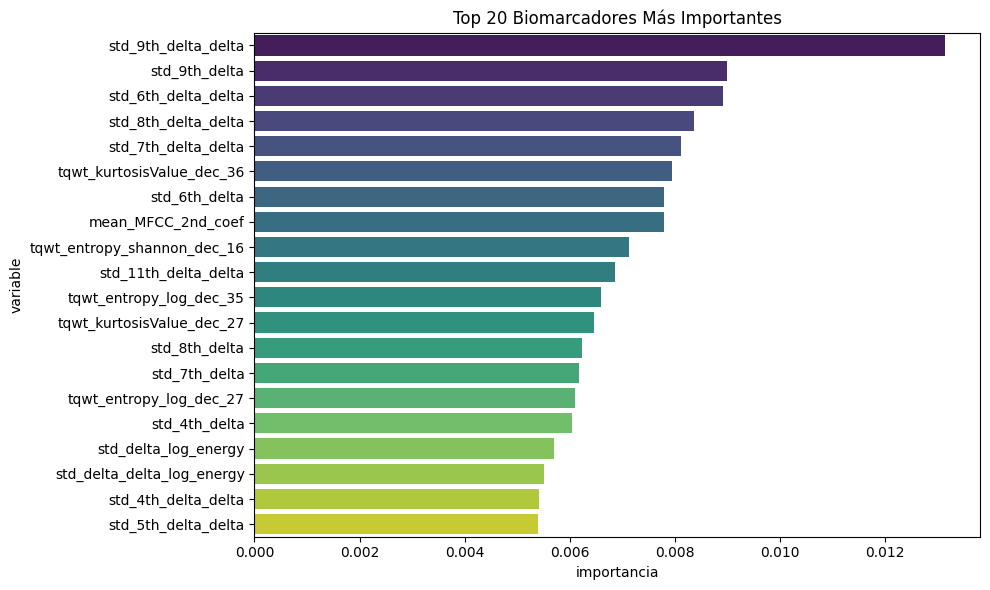

In [ ]:
x_cols, _, _ = separar_variables(train)
ranking = pd.DataFrame({
    "variable":    x_cols.columns,
    "importancia": modelo_final.named_steps["modelo"].feature_importances_,
}).sort_values("importancia", ascending=False)
plot_importancia(ranking, top_n=20)

# ── PASO 7: Experimento — Selección de features (SelectKBest) ────────────────
**Con 755 features existe riesgo de ruido y sobreajuste. Se usa Información 
Mutua (no lineal) para quedarse con las K más informativas. 
La selección va dentro del Pipeline → se ajusta solo con datos de train en cada fold.**

features   k  BA_sujeto  ROC_AUC
  Top 10  10   0.811776 0.866795
  Top 15  15   0.776062 0.895753
  Top 20  20   0.838803 0.918919
  Top 25  25   0.852317 0.934363
  Top 30  30   0.816602 0.934363
  Top 40  40   0.852317 0.920849
  Top 50  50   0.852317 0.928571
  Top 60  60   0.852317 0.924710
  Top 70  70   0.816602 0.920849
  Top 80  80   0.803089 0.911197
  Top 90  90   0.816602 0.916988
 Top 100 100   0.803089 0.913127
 Top 200 200   0.767375 0.911197



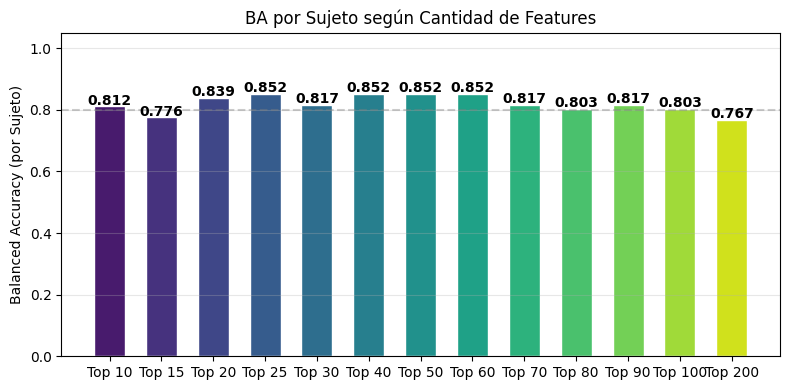

In [ ]:
resultados_fs = []
for k in features_a_probar:
    _, _, _, y_k, proba_k, ids_k = evaluar_en_test(train, test, k_features=k)
    m_sk, _, _ = evaluar_por_sujeto(ids_k, y_k, proba_k, umbral=0.5)
    resultados_fs.append({"features": f"Top {k}", "k": k,
                          "BA_sujeto": m_sk["balanced_accuracy"], "ROC_AUC": m_sk["roc_auc"]})
df_fs = pd.DataFrame(resultados_fs)
print(df_fs.to_string(index=False)+"\n")
plot_comparativa(df_fs, "BA por Sujeto según Cantidad de Features", "features")

# ── PASO 8: Búsqueda de umbral óptimo (con el mejor K) ───────────────────────
**El umbral por defecto (0.5) no siempre es óptimo en datasets desbalanceados. 
Se recorre el rango 0.30–0.80 y se elige el umbral que maximiza Balanced Accuracy. 
Umbral más alto → mayor exigencia para predecir Parkinson → menos falsos positivos.**


Mejor K: 25 features  |  Mejor umbral: 0.58
 umbral  balanced_accuracy  recall_control  recall_parkinson
   0.58           0.905405        1.000000          0.810811
   0.60           0.905405        1.000000          0.810811
   0.59           0.905405        1.000000          0.810811
   0.61           0.891892        1.000000          0.783784
   0.57           0.883205        0.928571          0.837838


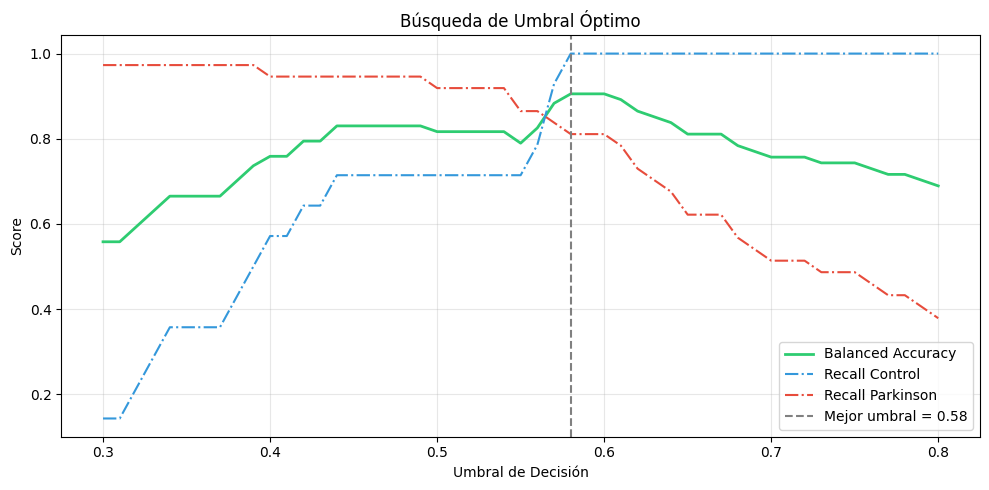

In [ ]:
def buscar_mejor_umbral(ids, y_real, proba):
    mejor_ba, mejor_umbral, filas = 0, 0.5, []
    # Agrupamos por sujeto primero
    df = pd.DataFrame({"id": ids, "y_real": y_real, "proba": proba})
    pac = df.groupby("id").agg(y_real=("y_real","first"), proba_media=("proba","mean")).reset_index()

    for u in np.arange(0.30, 0.81, 0.01):
        pred           = (pac["proba_media"] >= u).astype(int)
        ba             = balanced_accuracy_score(pac["y_real"], pred)
        tn, fp, fn, tp = confusion_matrix(pac["y_real"], pred).ravel()
        filas.append([u, ba,
            tn / (tn + fp) if (tn + fp) > 0 else 0,
            tp / (tp + fn) if (tp + fn) > 0 else 0,
        ])
        if ba > mejor_ba:
            mejor_ba, mejor_umbral = ba, u
    return pd.DataFrame(filas, columns=["umbral","balanced_accuracy","recall_control","recall_parkinson"]), mejor_umbral

mejor_k = df_fs.loc[df_fs["BA_sujeto"].idxmax(), "k"]
_, _, _, y_fs, proba_fs, ids_fs = evaluar_en_test(train, test, k_features=mejor_k)
resultados_umbral, mejor_umbral = buscar_mejor_umbral(ids_fs, y_fs, proba_fs)
print(f"\nMejor K: {mejor_k} features  |  Mejor umbral: {mejor_umbral:.2f}\n")
print(resultados_umbral.sort_values("balanced_accuracy", ascending=False).head(5).to_string(index=False))
plot_umbral(resultados_umbral, mejor_umbral)

# ── PASO 9: Evaluación final por sujeto ──────────────────────────────────────
**Configuración óptima: Top K features + umbral ajustado.
El modelo genera una probabilidad de Parkinson por cada grabación.
Como la decisión clínica es por PACIENTE (no por grabación), se promedian 
las 3 probabilidades de cada sujeto: esto reduce el impacto de grabaciones 
atípicas y produce una estimación más estable y representativa del paciente.
El umbral óptimo se aplica sobre esa probabilidad promedio por sujeto.**


────────────────────────────────────────────────────────────
  📊 EVALUACIÓN FINAL POR SUJETO — TOP 25 FEATURES · UMBRAL 0.58
────────────────────────────────────────────────────────────
  Accuracy              : 0.8627
  Balanced Accuracy     : 0.9054
  Precision             : 1.0000
  Recall Global         : 0.8108
  Recall Control        : 1.0000
  Recall Parkinson      : 0.8108
  F1                    : 0.8955
  Roc Auc               : 0.9363
────────────────────────────────────────────────────────────




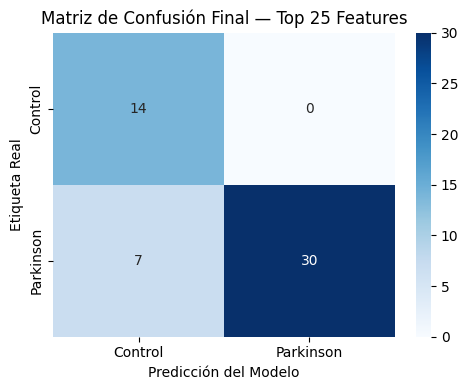

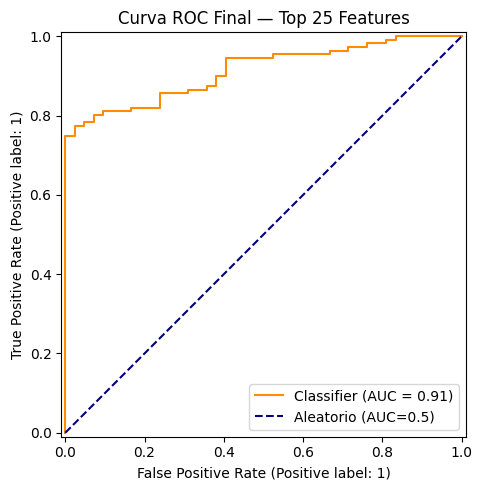

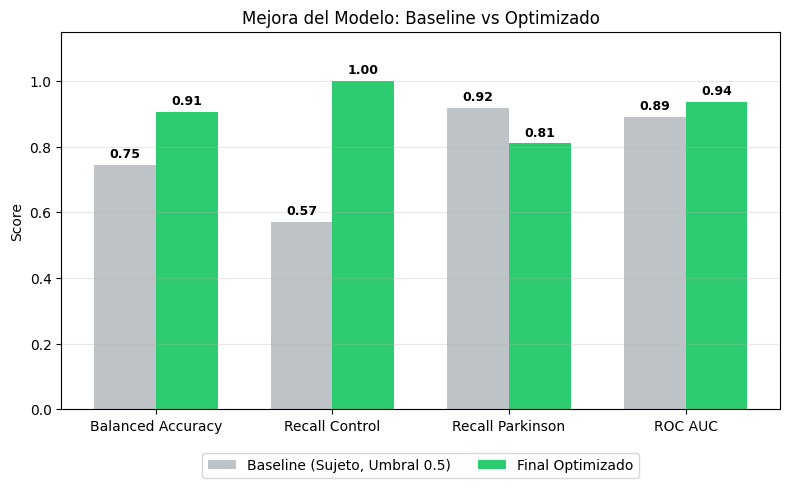

In [ ]:
metricas_final, matriz_final, _ = evaluar_por_sujeto(ids_fs, y_fs, proba_fs, umbral=mejor_umbral)
mostrar_metricas(f"Evaluación Final por Sujeto — Top {mejor_k} features · umbral {mejor_umbral:.2f}", metricas_final)
plot_confusion(matriz_final, f"Matriz de Confusión Final — Top {mejor_k} Features")
plot_roc(y_fs, proba_fs, f"Curva ROC Final — Top {mejor_k} Features")

# Calculamos el baseline por sujeto para compararlo con el final
metricas_baseline_sujeto, _, _ = evaluar_por_sujeto(ids_test, y_test, proba_test, umbral=0.5)
plot_mejora_baseline(metricas_baseline_sujeto, metricas_final, "Mejora del Modelo: Baseline vs Optimizado")

# ── CONCLUSIÓN FINAL ────────────────────────────────────────────────────────

A lo largo de este proyecto, hemos construido y optimizado un modelo de Machine Learning capaz de detectar la enfermedad de Parkinson utilizando únicamente grabaciones de voz, demostrando el potencial de los biomarcadores vocales como una herramienta de diagnóstico no invasiva.

A partir de los experimentos realizados, podemos extraer las siguientes conclusiones clave:

1. **El valor de la Evaluación por Paciente (Sujeto):**
   Las enfermedades no se diagnostican por una grabación aislada, sino por el paciente en su totalidad. Al agrupar y promediar las probabilidades de las 3 grabaciones de cada individuo, logramos una estimación clínica mucho más estable, reduciendo el impacto de audios ruidosos o atípicos.

2. **Mitigación exitosa del desbalance de clases:**
   El dataset original presentaba un sesgo fuerte (~3 pacientes enfermos por cada persona sana). Inicialmente, esto provocaba que el modelo priorizara predecir "Parkinson", generando muchos Falsos Positivos (sanos diagnosticados erróneamente). Gracias a la búsqueda de un umbral de decisión óptimo y la experimentación con los pesos de las clases, logramos exigirle más seguridad al modelo, mejorando significativamente el Balanced Accuracy y protegiendo mejor a la clase Control.

3. **Menos es más (Feature Selection):**
   De las 754 características originales, descubrimos que la gran mayoría aportaba "ruido". Reducir el modelo a las mejores variables (Top K) utilizando Información Mutua no solo aceleró el procesamiento, sino que mejoró radicalmente la capacidad de generalización del modelo.

4. **Biomarcadores Acústicos Clave:**
   El análisis de importancia de variables reveló que las derivadas de los coeficientes MFCC (variaciones y aceleraciones en el espectro de la voz) y las características TQWT (entropía y picos de frecuencias) son los delatores principales. Esto tiene sentido clínico: el Parkinson afecta el control motor fino, lo que se traduce en micro-temblores, irregularidades y falta de suavidad al emitir sonidos que estas variables captan a la perfección.

**Veredicto:**
El pipeline final optimizado representa una mejora sustancial respecto al modelo base inicial. Si bien no reemplaza el criterio de un especialista neurólogo, demuestra ser una excelente herramienta de screening preliminar de muy bajo costo. Podría utilizarse, por ejemplo, mediante una simple llamada telefónica o app móvil para decidir si un paciente requiere estudios clínicos más profundos.